In [1]:
#import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load our dataset

df = pd.read_csv("https://raw.githubusercontent.com/nilakshiGogoi/DmartAnalysis/refs/heads/main/Dmart.csv")

In [3]:
#data preview
df.head()

,Customer ID,Product ID,Order ID,Customer Age,Gender,Product Name,MRP,Discount Price,Category,State,...,Delivery Date,Cancellation Date,Payment Method,Pin Code,Total Order Value,Payment Status,No of Clicks,Year,Month,Shipping Charges
0,YSB75,BW653,479577309,28,Female,Ariel Matic Top Load Liquid Detergent,977.44,909.02,Imported,Andhra Pradesh,...,13-05-2022,NaN,Credit,318324,909.02,Paid,29,2022,May,0
1,FUS93,XV061,634865221,47,Male,VSR Channa Dal,834.09,450.41,Branded,Telangana,...,20-08-2021,NaN,Debit,730162,450.41,Paid,95,2021,August,0
2,AJP28,GF695,113166210,63,Female,Tenali Double Horse Chana Dal,1095.20,1007.58,Branded,Gujarat,...,26-10-2021,NaN,Debit,694091,1007.58,Paid,51,2021,October,0
3,URC55,VM478,740539230,41,Male,Tata Tea,748.16,389.04,Imported,Maharashtra,...,27-08-2021,NaN,Credit,211807,489.04,Pending,12,2021,August,100
4,ZOP23,XD230,156544145,22,Female,VSR Channa Dal,1249.04,911.80,Local,Gujarat,...,10-12-2023,NaN,Credit,78304,1011.8,Paid,26,2023,December,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              25000 non-null  object 
 1   Product ID               25000 non-null  object 
 2   Order ID                 25000 non-null  int64  
 3   Customer Age             25000 non-null  int64  
 4   Gender                   25000 non-null  object 
 5   Product Name             25000 non-null  object 
 6   MRP                      25000 non-null  float64
 7   Discount Price           25000 non-null  float64
 8   Category                 25000 non-null  object 
 9   State                    25000 non-null  object 
 10  City                     25000 non-null  object 
 11  Subscription             25000 non-null  object 
 12  Bill Number              25000 non-null  float64
 13  Time Spent on Website    25000 non-null  float64
 14  Rating                

In [5]:
#check for column based missing values
df.isna().sum()

Customer ID                    0
Product ID                     0
Order ID                       0
Customer Age                   0
Gender                         0
Product Name                   0
MRP                            0
Discount Price                 0
Category                       0
State                          0
City                           0
Subscription                   0
Bill Number                    0
Time Spent on Website          0
Rating                         0
Marketing/Advertisement        0
Ship Mode                      0
Order Status                   0
Orderdate                      0
Delivery Date                  0
Cancellation Date          23216
Payment Method                 0
Pin Code                       0
Total Order Value              0
Payment Status                 0
No of Clicks                   0
Year                           0
Month                          0
Shipping Charges               0
dtype: int64

In [6]:
#standardizing the column names
df.columns = df.columns.str.lower().str.replace(" ","_")

In [7]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges'],
      dtype='object')

Customer insights

In [8]:
#gender distribution
df["gender"].value_counts()

gender
Male      14250
Female    10750
Name: count, dtype: int64

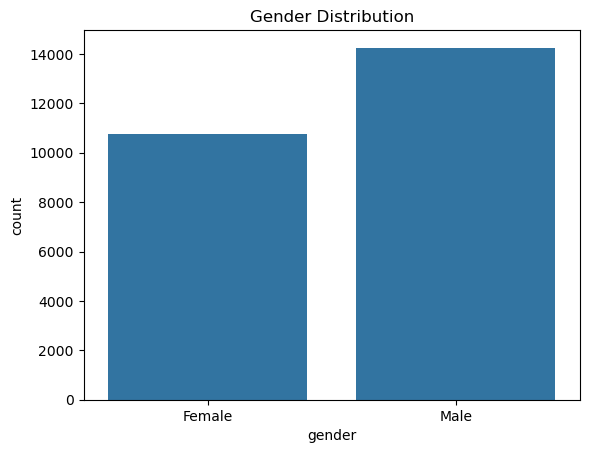

In [9]:
sns.countplot(x="gender",data=df)
plt.title("Gender Distribution")
plt.show()

Male customers are higher than female customers

In [10]:
# 0 to 25 years: KidsYA
# 26 to 45 years: Adults
# 46 to 60 years: MiddleAged
# 61 yeARS AND ABOVE 120: Seniors

df["age_group"] = pd.cut(df["customer_age"],bins=[0,26,46,61,120],labels=["KidsYA","Adults","MiddleAge","Seniors"])


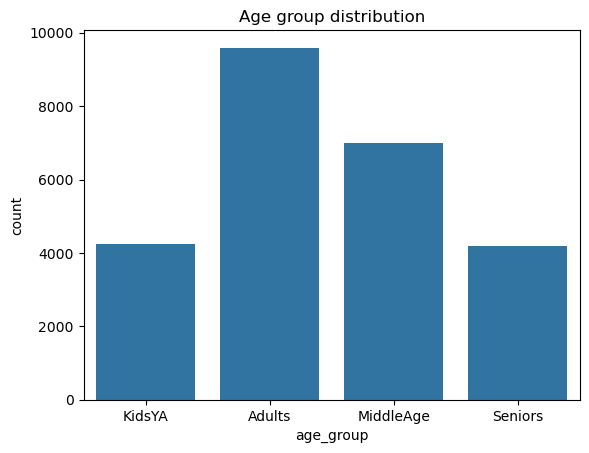

In [11]:
#age group distribution
sns.countplot(x="age_group",data=df)
plt.title("Age group distribution")
plt.show()

In [12]:
df.head()

,customer_id,product_id,order_id,customer_age,gender,product_name,mrp,discount_price,category,state,...,cancellation_date,payment_method,pin_code,total_order_value,payment_status,no_of_clicks,year,month,shipping_charges,age_group
0,YSB75,BW653,479577309,28,Female,Ariel Matic Top Load Liquid Detergent,977.44,909.02,Imported,Andhra Pradesh,...,NaN,Credit,318324,909.02,Paid,29,2022,May,0,Adults
1,FUS93,XV061,634865221,47,Male,VSR Channa Dal,834.09,450.41,Branded,Telangana,...,NaN,Debit,730162,450.41,Paid,95,2021,August,0,MiddleAge
2,AJP28,GF695,113166210,63,Female,Tenali Double Horse Chana Dal,1095.20,1007.58,Branded,Gujarat,...,NaN,Debit,694091,1007.58,Paid,51,2021,October,0,Seniors
3,URC55,VM478,740539230,41,Male,Tata Tea,748.16,389.04,Imported,Maharashtra,...,NaN,Credit,211807,489.04,Pending,12,2021,August,100,Adults
4,ZOP23,XD230,156544145,22,Female,VSR Channa Dal,1249.04,911.80,Local,Gujarat,...,NaN,Credit,78304,1011.8,Paid,26,2023,December,100,KidsYA


In [13]:
df["total_order_value"].dtype

dtype('O')

In [14]:
df["total_order_value"] = pd.to_numeric(df["total_order_value"],errors="coerce")

In [15]:
df["total_order_value"].dtype

dtype('float64')

In [16]:
df["total_order_value"].isna().sum()

np.int64(3134)

In [17]:
#Top spending groups

age_spend = df.groupby("age_group")["total_order_value"].sum()
age_spend = age_spend.reset_index()
age_spend

C:\Users\sippy\AppData\Local\Temp\ipykernel_24164\7012301.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = df.groupby("age_group")["total_order_value"].sum()


,age_group,total_order_value
0,KidsYA,2857991.02
1,Adults,6531575.89
2,MiddleAge,4754661.07
3,Seniors,2809881.35


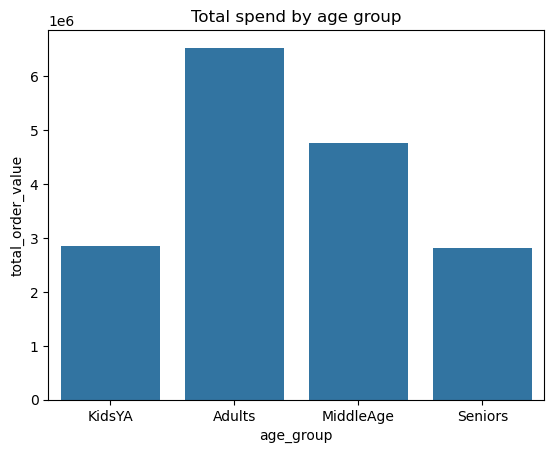

In [18]:
sns.barplot(x="age_group",y="total_order_value",data=age_spend)
plt.title("Total spend by age group")
plt.show()

In [19]:
#total spending for different genders
gender_spend = df.groupby("gender")["total_order_value"].sum()
gender_spend=gender_spend.reset_index()
gender_spend

,gender,total_order_value
0,Female,7265368.77
1,Male,9688740.56


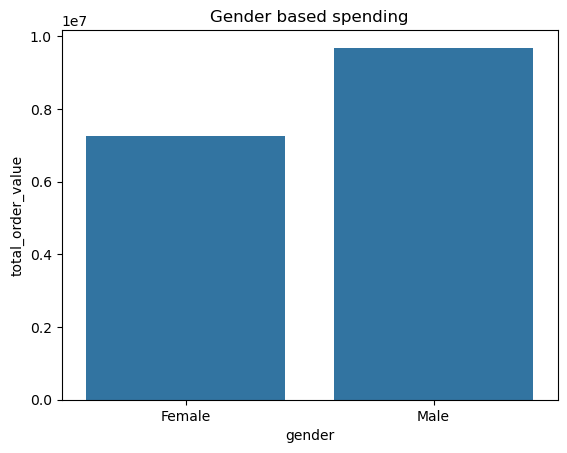

In [20]:
sns.barplot(x="gender",y="total_order_value",data=gender_spend)
plt.title("Gender based spending")
plt.show()

In [21]:
df['orderdate'].dtype

dtype('O')

In [22]:
df['orderdate']=pd.to_datetime(df['orderdate'],dayfirst=True)

In [23]:
#RFM segmentation

latest_date = df['orderdate'].max()
recency = df.groupby('customer_id')['orderdate'].max().apply(lambda x: (latest_date-x).days)

In [24]:
frequency = df.groupby('customer_id')['order_id'].count()
monetary= df.groupby('customer_id')['total_order_value'].sum()

In [25]:
rfm = pd.DataFrame({'Recency':recency,'Frequency':frequency,'Monetary':monetary})
rfm

,Recency,Frequency,Monetary
customer_id,,,
AAA09,489,1,0.00
AAA12,502,1,545.75
AAA79,981,1,0.00
AAB58,488,1,895.55
AAC08,482,1,690.90
...,...,...,...
ZZY23,756,1,105.66
ZZY44,440,1,850.61
ZZZ12,407,1,122.44


In [26]:
rfm['R']=pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F']=pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])
rfm['M']=pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])

rfm['RFM_score'] = rfm['R'].astype(str)+rfm['F'].astype(str)+rfm['M'].astype(str)

In [27]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_score
customer_id,,,,,,,
AAA09,489,1,0.00,3,1,1,311
AAA12,502,1,545.75,3,1,2,312
AAA79,981,1,0.00,1,1,1,111
AAB58,488,1,895.55,3,1,3,313
AAC08,482,1,690.90,3,1,3,313


In [28]:
df.head()

,customer_id,product_id,order_id,customer_age,gender,product_name,mrp,discount_price,category,state,...,cancellation_date,payment_method,pin_code,total_order_value,payment_status,no_of_clicks,year,month,shipping_charges,age_group
0,YSB75,BW653,479577309,28,Female,Ariel Matic Top Load Liquid Detergent,977.44,909.02,Imported,Andhra Pradesh,...,NaN,Credit,318324,909.02,Paid,29,2022,May,0,Adults
1,FUS93,XV061,634865221,47,Male,VSR Channa Dal,834.09,450.41,Branded,Telangana,...,NaN,Debit,730162,450.41,Paid,95,2021,August,0,MiddleAge
2,AJP28,GF695,113166210,63,Female,Tenali Double Horse Chana Dal,1095.20,1007.58,Branded,Gujarat,...,NaN,Debit,694091,1007.58,Paid,51,2021,October,0,Seniors
3,URC55,VM478,740539230,41,Male,Tata Tea,748.16,389.04,Imported,Maharashtra,...,NaN,Credit,211807,489.04,Pending,12,2021,August,100,Adults
4,ZOP23,XD230,156544145,22,Female,VSR Channa Dal,1249.04,911.80,Local,Gujarat,...,NaN,Credit,78304,1011.80,Paid,26,2023,December,100,KidsYA


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              25000 non-null  object        
 1   product_id               25000 non-null  object        
 2   order_id                 25000 non-null  int64         
 3   customer_age             25000 non-null  int64         
 4   gender                   25000 non-null  object        
 5   product_name             25000 non-null  object        
 6   mrp                      25000 non-null  float64       
 7   discount_price           25000 non-null  float64       
 8   category                 25000 non-null  object        
 9   state                    25000 non-null  object        
 10  city                     25000 non-null  object        
 11  subscription             25000 non-null  object        
 12  bill_number              25000 n

In [30]:
#monthly sales
monthly_orders = df.groupby(['year','month'])["total_order_value"].sum().reset_index()
monthly_orders

,year,month,total_order_value
0,2021,April,466983.55
1,2021,August,495260.02
2,2021,December,455027.34
3,2021,February,408273.45
4,2021,January,450818.55
5,2021,July,487640.18
6,2021,June,432757.23
7,2021,March,462025.11
8,2021,May,461050.08
9,2021,November,509504.80


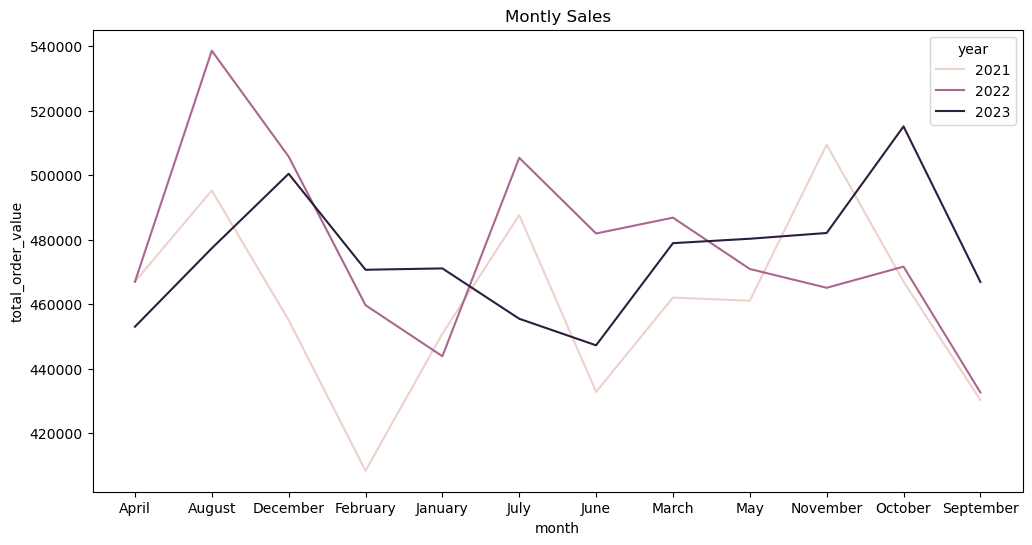

In [31]:
#line chart to see the trend
plt.figure(figsize=(12,6))
sns.lineplot(x='month',y='total_order_value',hue='year',data=monthly_orders)
plt.title("Montly Sales")
plt.show()

In [32]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['month'] = pd.Categorical(df['month'],categories=month_order,ordered=True)
df = df.sort_values('month')

C:\Users\sippy\AppData\Local\Temp\ipykernel_24164\3124473001.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_orders = df.groupby(['year','month'])["total_order_value"].sum().reset_index()


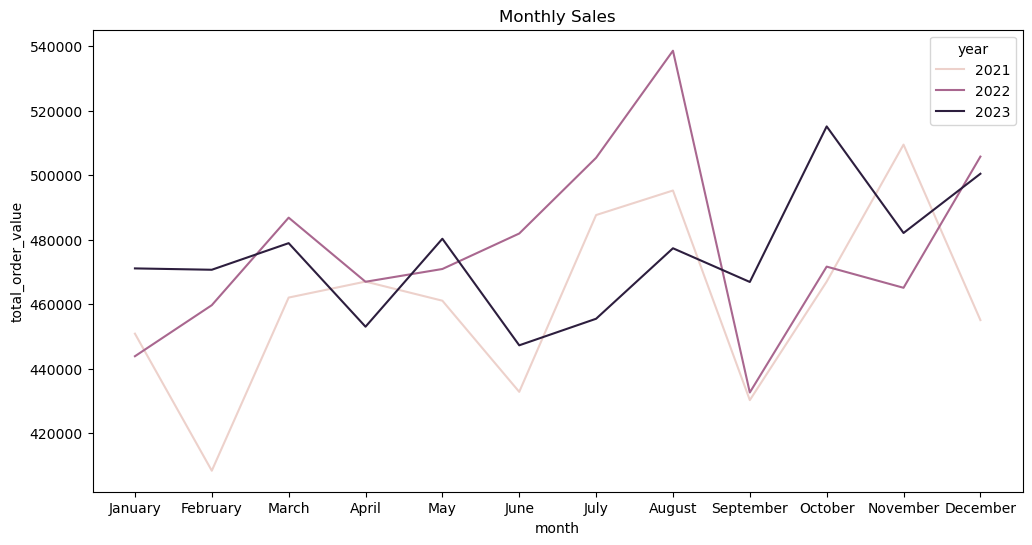

In [33]:
#line chart to see the trend
monthly_orders = df.groupby(['year','month'])["total_order_value"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='month',y='total_order_value',hue='year',data=monthly_orders)
plt.title("Monthly Sales")
plt.show()

In [34]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges', 'age_group'],
      dtype='object')

In [35]:
df['order_status'].unique()

array(['Delivered', 'Returned', 'Shipped', 'Cancelled'], dtype=object)

In [36]:
#cancellation rate

cancelled = df[df["order_status"]=='Cancelled']

cancel_rate = len(cancelled)/len(df)*100

print(f'The cancellation rate is {round(cancel_rate,2)}%')



The cancellation rate is 7.14%


In [37]:
len(cancelled)

1784

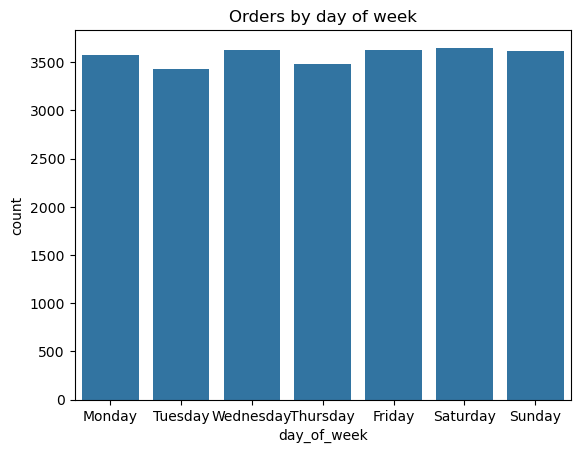

In [38]:
# Day wise orders
df['day_of_week'] =df['orderdate'].dt.day_name()
sns.countplot(x='day_of_week',data=df,order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Orders by day of week")
plt.show()

In [39]:
df['shipping_charges']=pd.to_numeric(df["shipping_charges"],errors='coerce')

In [40]:
#shipping fee impact
df["ship_feeimpact"] =df['shipping_charges'].apply(lambda x:'Free Shipping' if x==0 else 'Paid Shipping')


In [41]:
df['ship_feeimpact'].value_counts()

ship_feeimpact
Free Shipping    13149
Paid Shipping    11851
Name: count, dtype: int64

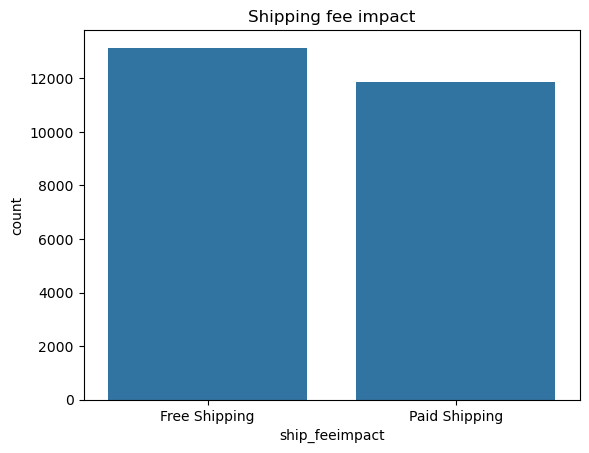

In [42]:
sns.countplot(x='ship_feeimpact',data=df)
plt.title("Shipping fee impact")
plt.show()

<Axes: xlabel='shipping_charges', ylabel='Count'>

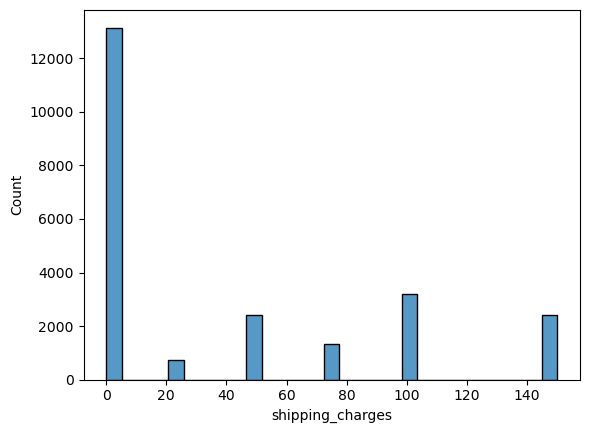

In [43]:
sns.histplot(df["shipping_charges"])

In [44]:
df["shipping_charges"].dtype

dtype('float64')

In [45]:
df["city"].nunique()

40

In [46]:
#orders per city (top cities)

top_cities = df['city'].value_counts().head(10)

In [47]:
top_cities

city
Vadodara         679
Guntur           678
Navi Mumbai      678
Suryapet         669
Visakhapatnam    657
Rajahmundry      648
Bharuch          648
Thane            645
Aurangabad       643
Nagpur           643
Name: count, dtype: int64

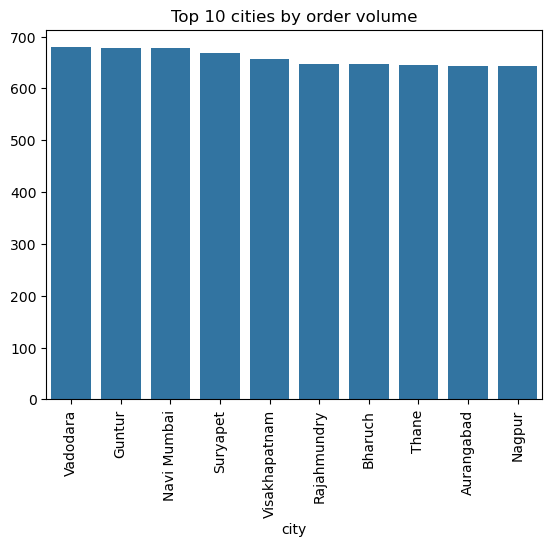

In [48]:
sns.barplot(x=top_cities.index,y=top_cities.values)
plt.title("Top 10 cities by order volume")
plt.xticks(rotation=90)
plt.show()

In [49]:
df['category'].unique()

array(['Imported', 'Local', 'Branded'], dtype=object)

In [50]:
#category dominance
df['category'].value_counts()

category
Local       12402
Branded      7564
Imported     5034
Name: count, dtype: int64

In [51]:
# Average spending for every category
local_p = df[df['category']=='Local']['total_order_value'].mean()
nonlocal_p = df[df['category']!='Local']['total_order_value'].mean()
print(f'The avg local spending is {round(local_p,2)} and for nonlocal the avg spending is {round(nonlocal_p,2)}')

The avg local spending is 780.17 and for nonlocal the avg spending is 770.61


In [52]:
# top products
top_products = df['product_name'].value_counts().head(10)

In [53]:
top_products

product_name
Parle Nutricrunch Digestive Cookies           1212
Harpic Bathroom Cleaner - Floral              1205
Wagh Bakri Masala Tea                         1193
Tata Sampann Moong Dal (Pesara Pappu)         1186
Tata Tea Chakra Gold Premium Tea              1168
Nutri Delite Breakfast Cereal                 1166
Cavin's Chocolate Milkshake                   1165
Ariel Matic Top Load Liquid Detergent         1145
Nimyle Herbal Anti-Bacterial Floor Cleaner    1143
Usha Heavy Weight Iron - El3710: 1000 W       1143
Name: count, dtype: int64

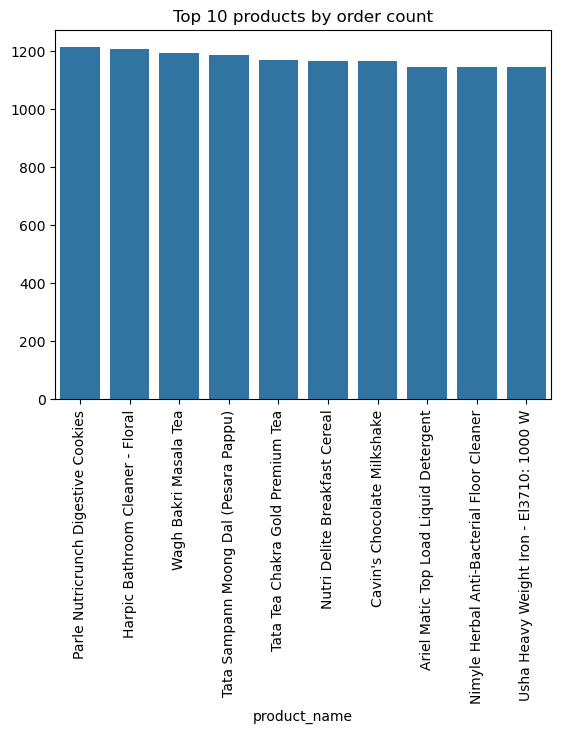

In [54]:
sns.barplot(x=top_products.index,y=top_products.values)
plt.title("Top 10 products by order count")
plt.xticks(rotation=90)
plt.show()

In [55]:
#conversion_rate
#high mrp,low discount

df['discount%']=(df['mrp']-df['discount_price'])/df['mrp']*100
#all rows with high mrp(top 10%) and low discount(less than 10%)
hmld = df[(df['mrp']>df['mrp'].quantile(0.9)) & (df['discount%']<10)]
conversion_rate = len(hmld[hmld['order_status']=="Delivered"])/len(hmld)*100
print(f"The coversion rate is {round(conversion_rate,0)}%")

The coversion rate is 50.0%


In [56]:
#category wise discount percentage
cat_discount = df.groupby('category')['discount%'].mean().reset_index()
cat_discount

,category,discount%
0,Branded,27.355779
1,Imported,27.570921
2,Local,27.447191


In [57]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges', 'age_group', 'day_of_week', 'ship_feeimpact',
       'discount%'],
      dtype='object')

In [58]:
df['payment_method'].unique()

array(['COD', 'Debit', 'Credit', 'UPI', 'Netbanking', 'Cancelled'],
      dtype=object)

In [59]:
#cash vs digital
digital = df[df['payment_method'].isin(['Debit', 'Credit', 'UPI', 'Netbanking'])]
cod = df[df['payment_method']=="COD"]

print(f"Digital avg order value: {digital['total_order_value'].mean()}, Cod : {cod['total_order_value'].mean()}")

Digital avg order value: 775.8547950878883, Cod : 766.1076385104451


In [60]:
len(digital)

22052

In [61]:
len(cod)

1164

In [62]:
# Revenue concentration
customer_rev = df.groupby('customer_id')['total_order_value'].sum().sort_values(ascending=False)
customer_rev

customer_id
PLB80    3389.27
OYU88    3133.41
KVO58    3022.27
DKI77    2961.66
MQC85    2928.17
          ...   
SAE76       0.00
MHY24       0.00
WOS37       0.00
WOW14       0.00
AAA09       0.00
Name: total_order_value, Length: 24814, dtype: float64

In [63]:
top_10p = int(0.1 *len(customer_rev))

In [64]:
top_10p

2481

In [65]:
rev_top10 = customer_rev.head(top_10p).sum()/customer_rev.sum()*100
print(f"Top 10% customers contribute {round(rev_top10,0)}% of revenue")

Top 10% customers contribute 23.0% of revenue


In [66]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges', 'age_group', 'day_of_week', 'ship_feeimpact',
       'discount%'],
      dtype='object')

In [67]:
df['marketing/advertisement'].unique()

array(['Facebook', 'Instagram', 'TV', 'Other', 'Friends'], dtype=object)

In [68]:
# Social media impacts
roi = df.groupby('marketing/advertisement')['total_order_value'].mean().sort_values(ascending=False)
print(roi)

marketing/advertisement
Other        793.302705
Facebook     774.806972
Instagram    772.407276
TV           769.500072
Friends      767.714544
Name: total_order_value, dtype: float64


In [69]:
# marketing reach
traffic = df['marketing/advertisement'].value_counts()
delivered = df[df['order_status']=='Delivered']['marketing/advertisement'].value_counts()
delivered

marketing/advertisement
Instagram    4404
Facebook     3264
Friends      2148
Other        2099
TV           1094
Name: count, dtype: int64